# Probabilistic Multiplexer and Kernel Density Estimation (KDE)

---

## **Overview**

Design a probabilistic multiplexer to generate samples from a mixture distribution. The 
mixture combines three one-dimensional Gaussian random generators, each with distinct 
mean and variance parameters, and each selected with probability p₁, p₂, and p₃ 
respectively (where p₁ + p₂ + p₃ = 1). The generated samples must satisfy the conditions of a 
valid probability density function (PDF): non-negativity and unit integral.

**Part 1.** 
Large-Scale Sampling and Visualization (n = 10,000)

Generate **n = 10,000 samples** from the mixture distribution using your probabilistic multiplexer.

- Plot a **normalized histogram** of the generated samples.  
- Overlay the **true analytical mixture PDF** for comparison.  
- Verify visually that the **empirical distribution** converges to the theoretical PDF.

---

### Defining the Mixture Model Parameters

The first step is to define the parameters of the **three one-dimensional Gaussian functions**.

- In previous lectures, a single Gaussian model required only the **mean** and **standard deviation**.  
- For a **mixture model**, we also need to assign a **probability weight** to each Gaussian. This ensures that the total mixture model satisfies the properties of a valid **probability density function (PDF)**.

### Properties of a PDF

A valid PDF, $p(x)$, must satisfy the following conditions:

1. **Non-negativity**:  

$$
p(x) \ge 0 \quad \text{for all } x
$$

2. **Unit integral**:  

$$
\int_{-\infty}^{\infty} p(x) \, dx = 1
$$

---

### Mixture PDF (as in the lecture PPT)

For a mixture of $J$ Gaussian components:

$$
p(x) = \sum_{j=1}^{J} P_j \, N(x \mid \mu_j, \sigma_j)
$$

Where the weights satisfy:

$$
\sum_{j=1}^{J} P_j = 1 \quad \text{and} \quad 0 \le P_j \le 1
$$

This guarantees that the mixture PDF is **non-negative** and has a **total integral equal to 1**.

---

### Sampling from the Mixture

Each sample is generated using a **random value (r-value)** between 0 and 1:  

1. The r-value is used in conjunction with the **component weights $P_j$** to determine which Gaussian component will generate the sample.  
2. Once the component is selected, its **mean $\mu_j$** and **standard deviation $\sigma_j$** are used to generate the final sample value.

In [1]:
import numpy as np

#Gaussian function params
mean = [0, 5, 10]
stdev = [1, 1.5, 2]
p_weight = [0.2, 0.4, 0.4]

#function for generating samples from the multiplexer PDF
def generate_samples(n_samples):
    samples = []

    for _ in range(n_samples):
        r = np.random.rand()

        if r < p_weight[0]:
            samples.append(np.random.normal(mean[0], stdev[0]))
        elif r < p_weight[0]+ p_weight[1]:
            samples.append(np.random.normal(mean[1], stdev[1]))
        else:
            samples.append(np.random.normal(mean[2], stdev[2]))
    return np.array(samples)

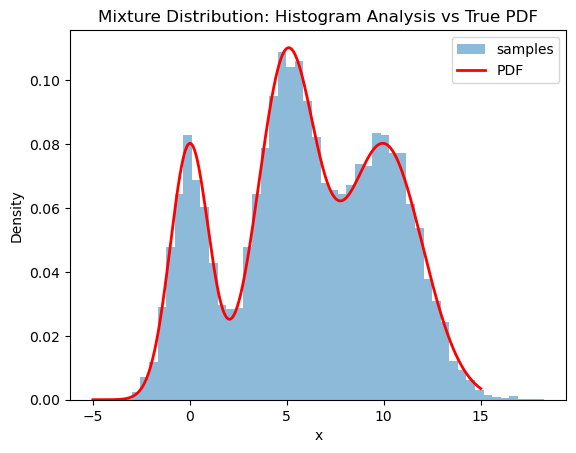

In [2]:
from scipy.stats import norm
import matplotlib.pyplot as plt

def mixture_pdf(x):
    return (p_weight[0]*norm.pdf(x, mean[0], stdev[0]) + p_weight[1]*norm.pdf(x, mean[1], stdev[1]) + p_weight[2]*norm.pdf(x, mean[2], stdev[2]))

#generate samples
n_samples = 10000
sample_mixture = generate_samples(n_samples)

#plot histogram of samples over mixture PDF
x_vals = np.linspace(-5, 15, 1000)
plt.hist(sample_mixture, bins=50, density=True, alpha=0.5, label='samples')
plt.plot(x_vals, mixture_pdf(x_vals), 'r', lw=2, label='PDF')
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Mixture Distribution: Histogram Analysis vs True PDF')
plt.legend()
plt.show()

### Histogram and PDF Overlay

After generating $n = 10,000$ samples from the mixture model using the probabilistic multiplexer, a **normalized histogram** (using 50 bins) was plotted and overlaid with the **true mixture PDF**.

* **Convergence:** Visually, the empirical histogram converges to the theoretical PDF, confirming that the sampling procedure correctly approximates the mixture distribution.
* **Bias-Variance Tradeoff:** The choice of 50 bins serves as a middle ground for density estimation. **Increasing** the bin count would reduce bias but **increase variance**, making the histogram appear noisy and sensitive to local fluctuations.
**Decreasing** the bin count would smooth the appearance (lower variance) but **increase bias**, potentially masking the distinct features of the Gaussian components.
  
* **Results:** With the current parameters, the **variance across bins is relatively low**, indicating stable sampling, while the low bias ensures the empirical distribution closely matches the true PDF.

This demonstrates that a histogram analysis in the case of **large-scale sampling** effectively reproduces the characteristics of the mixture model and that the probabilistic multiplexer approach provides a reliable method for drawing samples from weighted Gaussian components.

---


**Part 2.**
Kernel Density Estimation and RMS Error (n = 10)

Generate *n* = 10 samples from the mixture distribution.

1. Use these 10 samples as the **discovery set** to estimate the PDF via Kernel Density Estimation (KDE) with a fixed kernel bandwidth *h*.
2. Generate 10 additional samples not used in KDE construction. This is the **replication set**.
3. Compute the Root-Mean-Square (RMS) error between the KDE estimate and the true mixture PDF, evaluated separately on:
   - The **discovery set** (the 10 points used to build the KDE)
   - The **replication set** (10 new, unseen points)
4. Repeat the experiment 50 times, each time drawing a fresh discovery set and replication set of 10 samples each.
5. Compute the average RMS error over the 50 trials for both the discovery set and the replication set.
6. Report and compare the two RMS errors. Discuss any differences observed.


### KDE Implementation

**Gaussian Kernel**

Rather than the hypercube (Parzen window) approach - which counts samples inside a box of width $h$ and produces a discontinuous PDF - we use the Gaussian kernel for a smoother estimate. Where the hypercube formula is:

$$\varphi(u) = \begin{cases} 1 & |u| \leq 1/2 \\ 0 & \text{otherwise} \end{cases}$$

the Gaussian kernel replaces the hard box boundary with a smooth bell curve, giving nearby samples a high weight and distant samples a smoothly decaying weight rather than a sharp cutoff:

$$\varphi(u) = \frac{1}{\sqrt{2\pi}} e^{-\frac{1}{2}u^2}$$

where $u = \dfrac{x - x^n}{h}$ is the **normalized distance** between the evaluation point $x$ and a training sample $x^n$, scaled by bandwidth $h$. This is equivalent to a standard normal PDF centered at zero — samples close to $x$ produce $u \approx 0$ (peak contribution), while distant samples produce large $|u|$ (near-zero contribution).  

---

**Kernel Density Estimator**

$$\hat{p}(x) = \frac{1}{Nh} \sum_{n=1}^{N} \varphi\left(\frac{x^n - x}{h}\right)$$

For each evaluation point $x$, we place a Gaussian bump centered at every training point $x^n$, scaled by bandwidth $h$. The estimate is the average of all $N$ bumps — narrow $h$ produces a spiky estimate that hugs the data, wide $h$ produces a smoother but more biased estimate.

---

**Root Mean Square (RMS) Error**

$$\text{RMS} = \sqrt{\frac{1}{M} \sum_{i=1}^{M} \left(\hat{p}(x_i) - p(x_i)\right)^2}$$

Measures the average deviation between the KDE estimate $\hat{p}(x)$ and the true mixture PDF $p(x)$, evaluated at $M$ points. Lower RMS indicates the KDE is a better approximation of the true distribution.

In [3]:
#implementation of the KDE functions

#Gaussian kernel is smoother result than the hypercube approach
def gaussian_kernel(u):
    return (1/np.sqrt(2*np.pi))*np.exp(-0.5*u**2)

def kde(eval_points, training_points, h):
    result = np.zeros(len(eval_points))
    n = len(training_points)

    for i, x in enumerate(eval_points):
        #normalized distance
        u = (x-training_points)/h
        result[i] = np.sum(gaussian_kernel(u))/(n*h)
    return result

def rms_error(kde_res, true_res):
    return np.sqrt(np.mean((kde_res-true_res)**2))

### Experimental Procedure

We repeat the following procedure 50 times to average out the randomness from small sample sizes:

1. Draw a **discovery set** of $n = 10$ samples — used to build the KDE
2. Draw a **replication set** of $n = 10$ fresh samples — never seen by the KDE
3. Evaluate the KDE at both sets and compute RMS error against the true mixture PDF at those same points
4. Average RMS over all 50 trials for each set

The key distinction is where the RMS is evaluated:
- **Discovery RMS** — the KDE is evaluated at the same points it was built from, so each point benefits from its own kernel bump centered on itself
- **Replication RMS** — evaluated at unseen points, giving an honest measure of generalization

With $n = 10$ the results are noisy and the expected pattern (discovery RMS $<$ replication RMS) may not always hold — this variance itself is part of what the experiment illustrates.

In [4]:
def run_trial(n, h):
    #new set of samples for each trial
    discovery_set = generate_samples(n)
    replication_set = generate_samples(n)

    #evalutation of KDE (built on each discocovery set)
    kde_discovery = kde(discovery_set, discovery_set, h)
    kde_replication = kde(replication_set, discovery_set, h)

    #RMS of KDE vs true PDF points
    discovery_rms = rms_error(kde_discovery, mixture_pdf(discovery_set))
    replication_rms = rms_error(kde_replication, mixture_pdf(replication_set))

    return discovery_rms, replication_rms

#new experiment method
def run_experiment(n, h, n_trials):
    disc_rms = np.zeros(n_trials)
    rep_rms = np.zeros(n_trials)

    for trial in range(n_trials):
        disc_rms[trial], rep_rms[trial] = run_trial(n, h)

    return np.mean(disc_rms), np.mean(rep_rms)
    
def plot_KDE(n, h):
    x_grid = np.linspace(-5, 15, 1000)
    disc_ex = generate_samples(n)
    rep_ex  = generate_samples(n)
    
    plt.figure(figsize=(10, 4))
    plt.plot(x_grid, mixture_pdf(x_grid), 'k-',  lw=2, label='True PDF')
    plt.plot(x_grid, kde(x_grid, disc_ex, h), 'b--', lw=2, label=f'KDE (h={h:.2f})')
    plt.scatter(disc_ex, np.zeros(n), color='blue', zorder=5, label='Discovery set')
    plt.scatter(rep_ex,  np.zeros(n), color='red',  zorder=5, marker='x', label='Replication set')
    plt.title('KDE vs True Mixture PDF (example trial)')
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()


Average RMS Error — Discovery Set:   0.0901
Average RMS Error — Replication Set: 0.0584


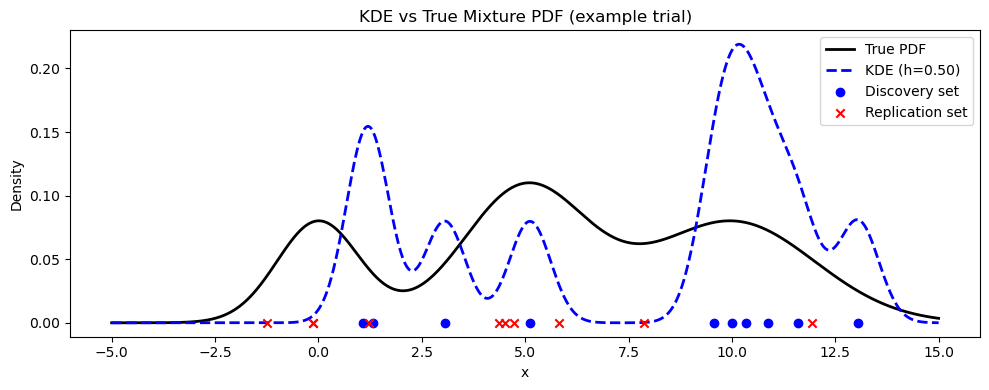

In [5]:
#experiment portion of implementation
n = 10 #samples per set
h = 0.5 #fixed kernel bandwidth
n_trials = 50 #number of repeated experiments

discovery_avg, replication_avg = run_experiment(n, h, n_trials)

print(f"Average RMS Error — Discovery Set:   {discovery_avg:.4f}")
print(f"Average RMS Error — Replication Set: {replication_avg:.4f}")

plot_KDE(n, h)

### Results: Fixed Bandwidth (h = 0.5, n = 10)

Contrary to the expected pattern, the replication set yielded a lower average RMS error than the discovery set. This is attributed to the small sample size $n=10$. 

When the KDE is evaluated at the discovery points - the same points used to build it - each point recieves a large contribution from its own kernel bump centered directly on top of it. With a relatively narrow bandwidth of $h=0.5$ and only $n=10$ samples, these contributions cause the KDE to overestimate the denisty at training points, producing a higher RMS error when evaluated against the true PDF.

By contrast, the replication set is generated fresh from the true PDF and tends to land in the high-density areas near each Gaussian function's means. The KDE built on the discovery set also concentrates density in these same regions, so the two happen to agree reasonably well - yielding a lower RMS.

---

**Part 3:**
Effect of Kernel Bandwidth (50 Trials per Bandwidth, n = 10)

Repeat Part 2 across a range of kernel bandwidths $h$.

- For each bandwidth, compute the average RMS error over the 50 trials for both the 
discovery set and the replication set.
- Plot the average RMS error as a function of bandwidth $h$ for both sets on the same figure.
- Use a meaningful range of bandwidths (e.g., from very small to very large relative to 
the data spread).

In [6]:
from matplotlib.ticker import FixedLocator, FixedFormatter

#run experiments with different h-values
def sweep_bandwidths(n, h_values, n_trials):
    disc_y_set = np.zeros(len(h_values))
    rep_y_set = np.zeros(len(h_values))

    for i, h in enumerate(h_values):
        discovery_avg, replication_avg = run_experiment(n, h, n_trials)

        disc_y_set[i] = discovery_avg
        rep_y_set[i] = replication_avg

    return disc_y_set, rep_y_set

def plot_h_values(disc_y_set, rep_y_set, h_values):
    plt.figure(figsize=(10, 4))
    plt.plot(h_values, disc_y_set, 'r--', lw=2, label='Discovery Sets')
    plt.plot(h_values, rep_y_set, 'b--', lw=2, label='Replication Sets')
    plt.xscale('log')
    
    ticks = [0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 30.0]
    plt.gca().xaxis.set_major_locator(FixedLocator(ticks))
    plt.gca().xaxis.set_major_formatter(FixedFormatter([str(t) for t in ticks]))
    
    plt.title('Average RMS Value vs Bandwidth Size')
    plt.xlabel('H-Value (Bandwidth)')
    plt.ylabel('RMS Value')
    plt.legend()
    plt.tight_layout()
    plt.show()

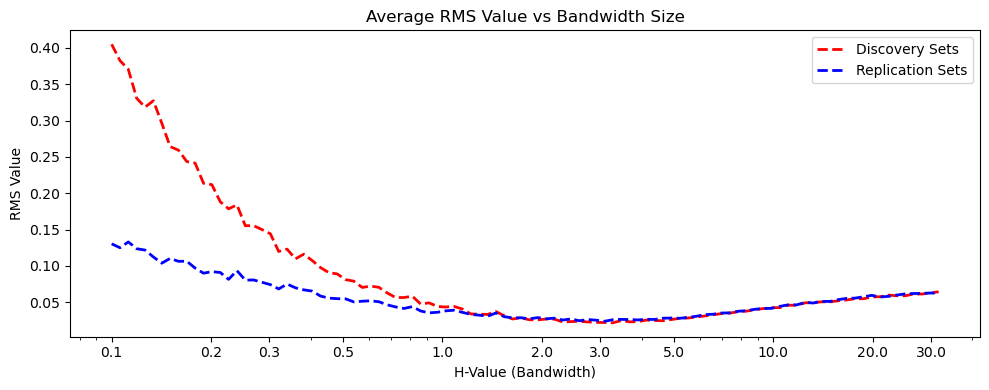

In [7]:
from matplotlib.ticker import FixedLocator, FixedFormatter

#experimental procedure
n = 10 #number of samples
h_values = np.logspace(-1, 1.5, 100)  # 0.1 to ~32, 100 points
n_trials = 50 #number of trials per h-value

disc_y_set, rep_y_set = sweep_bandwidths(n, h_values, n_trials)

plot_h_values(disc_y_set, rep_y_set, h_values)

**Part 4.**
Discussion: Bias–Variance Trade-off and Kernel Bandwidth

Based on the plots from Part 3, provide a written analysis addressing the following:

- How does increasing the bandwidth affect the bias of the KDE estimator? What happens 
to the estimated PDF shape?

- How does decreasing the bandwidth affect the variance of the KDE estimator?

- Where is the optimal bandwidth located relative to the discovery and replication RMS 
curves, and what does this tell us about overfitting?

- Explain why the discovery set RMS error and the replication set RMS error diverge at 
extreme bandwidth values.

- Connect your observations to the general bias–variance trade-off in nonparametric 
density estimation.

### Discussion: Bias–Variance Trade-off and Kernel Bandwidth (n = 10)

Increasing the bandwidth of a KDE estimator results in a larger bias, meaning that the 
estimated PDF shape strays from the actual PDF shape more significantly, which is 
undesirable and leads to an underfitted model. Decreasing the bandwidth, in contrast, 
results in a larger variance, meaning that while the overall PDF shape converges on the 
true PDF, it is not generalised enough to provide a good estimation for the population, 
leading to an overfitted model.

For this particular sample size, the optimal bandwidth value appears to be $2.0 < h < 3.0$ 
when visually studying the RMS error vs bandwidth plot. At this range the RMS error curve 
reaches its minimum, indicating the best balance between bias and variance for $n = 10$.

The discovery and replication RMS curves diverge most significantly at small $h$, where 
the self-contribution effect inflates the discovery RMS — each training point receives a 
large spike from its own kernel bump, causing the KDE to overestimate density at those 
points. At large $h$ the two curves converge as the kernels become so wide that no single 
point's self-contribution is meaningful relative to the rest.

This demonstrates the fundamental bias–variance trade-off in nonparametric density 
estimation. Unlike parametric models which have a fixed number of parameters, the KDE has 
no assumed shape — bandwidth $h$ is the sole regularisation parameter controlling model 
complexity. Too small an $h$ produces a model that memorises the training data (overfitting); too large 
an $h$ produces a model that is too rigid to capture the true structure (underfitting). The optimal $h$ 
is the point where the bias and variance trade-offs are balanced, which is precisely what the 
minimum of the replication RMS curve identifies.

---

**Part 5.**
Effect of Sample Size: Repeat Parts 2–3 with n = 100

Repeat the full procedure from Parts 2 and 3 using n = 100 samples for both the discovery 
and replication sets. Then, plot figures and provide a written comparison addressing:

- How does increasing n from 10 to 100 affect the overall magnitude of the RMS error?

- How does the optimal bandwidth shift as n increases?

- How does sample size influence the bias and variance of the KDE estimate independently?

- What does this suggest about the relationship between sample size and bandwidth selection 
in practice?

Average RMS Error — Discovery Set:   0.0193
Average RMS Error — Replication Set: 0.0183


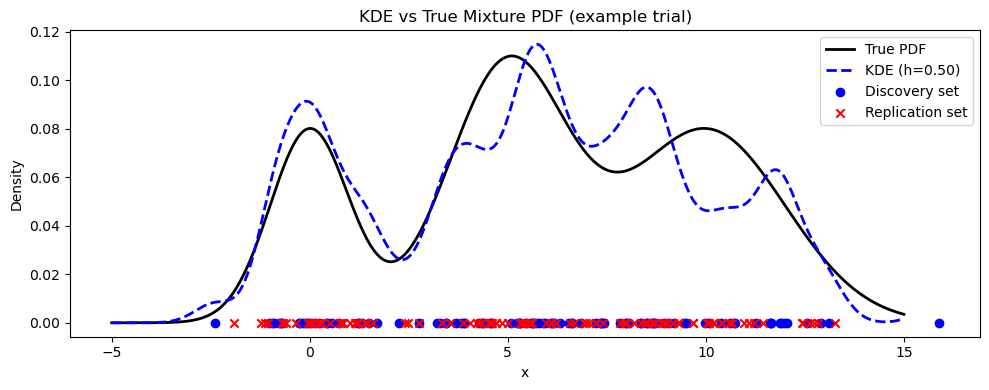

In [8]:
#experiment portion of implementation
n = 100 #samples per set
h = 0.5 #fixed kernel bandwidth
n_trials = 50 #number of repeated experiments

discovery_avg, replication_avg = run_experiment(n, h, n_trials)

print(f"Average RMS Error — Discovery Set:   {discovery_avg:.4f}")
print(f"Average RMS Error — Replication Set: {replication_avg:.4f}")

plot_KDE(n, h)

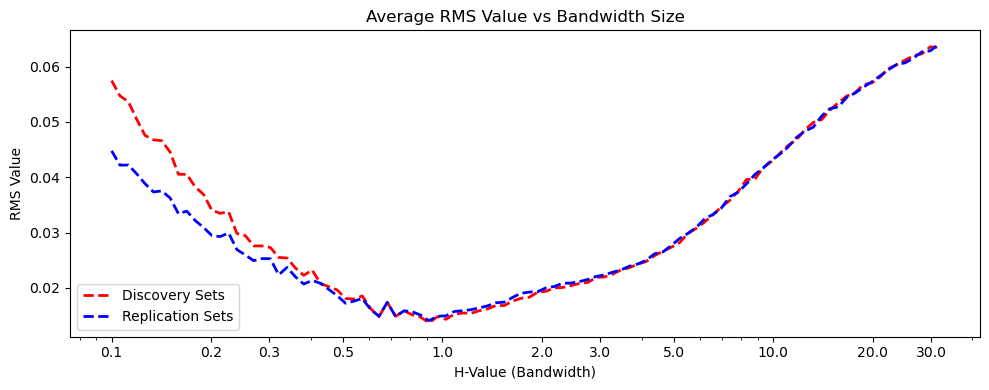

In [9]:
#experimental procedure
n = 100 #number of samples
h_values = np.logspace(-1, 1.5, 100)  # 0.1 to ~32, 100 points
n_trials = 50 #number of trials per h-value

disc_y_set, rep_y_set = sweep_bandwidths(n, h_values, n_trials)

#plotting
plt.figure(figsize=(10, 4))
plt.plot(h_values, disc_y_set, 'r--', lw=2, label='Discovery Sets')
plt.plot(h_values, rep_y_set, 'b--', lw=2, label='Replication Sets')
plt.xscale('log')

ticks = [0.1, 0.2, 0.3, 0.5, 1.0, 2.0, 3.0, 5.0, 10.0, 20.0, 30.0]
plt.gca().xaxis.set_major_locator(FixedLocator(ticks))
plt.gca().xaxis.set_major_formatter(FixedFormatter([str(t) for t in ticks]))

plt.title('Average RMS Value vs Bandwidth Size')
plt.xlabel('H-Value (Bandwidth)')
plt.ylabel('RMS Value')
plt.legend()
plt.tight_layout()
plt.show()

### Discussion: Effect of Increasing Sample Size on KDE Estimate (n = 100)

By increasing the sample size, the RMS error for the fixed bandwidth value was reduced. 
With $n = 100$ and a bandwidth value of $h = 0.5$, the original pattern of the discovery 
set having a greater RMS error is preserved, however both values were reduced. When the 
new sample size was evaluated for an optimal bandwidth, it showed that $h \approx 1$ is 
the new value that would provide the best bias-variance trade-off (lowest RMS error).

**Effect on variance:** A larger $n$ directly reduces variance in the KDE estimate — with 
more samples drawn each trial, the discovery and replication sets are more representative 
of the true distribution, meaning the KDE is less sensitive to which specific points were 
drawn. This is visible in the plot as the discovery and replication curves converge much 
more tightly at $n = 100$ compared to $n = 10$.

**Effect on bias:** Bias is also reduced independently, as more points naturally cluster 
around the true component means ($\mu = 0, 5, 10$), allowing the KDE to recover the true 
PDF shape more accurately even at moderate bandwidths. The overall RMS magnitude drops 
from ~0.40 at small $h$ with $n = 10$ to ~0.06 with $n = 100$, reflecting this combined 
reduction in both bias and variance.

Together, these effects demonstrate that increasing sample size addresses both sources of 
error simultaneously — more data reduces variance by stabilising the estimate across trials, 
and reduces bias by providing denser coverage of the true distribution. This explains the 
inverse relationship between sample size and optimal bandwidth: as $n$ grows, variance is 
naturally controlled by the data density itself, allowing a smaller $h$ to be used without 
the estimate becoming unstable.